In [ ]:
import pandas as pd
import numpy as np
import importlib

import plotly.express as px

import irina.utility_functions as uf

In [ ]:
start_year = 1970
end_year = 2023
year_list = range(1970, 2023)
mode = "individual_"

In [ ]:
df_prob_yearly_list = []

for year_loop in year_list:
    df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}{year_loop}.csv", index_col=0)
    df_prob_yearly_list.append(
        df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop)
    )

df_prob_yearly = pd.concat(df_prob_yearly_list)

In [ ]:
df_prob_yearly

In [ ]:
country = "BY"
df_country = (
    df_prob_yearly
    .query("country == @country")
    .drop("country", axis=1)
    .set_index("year")
)
# df_country

In [ ]:
df_dist = uf.get_jaccard_distances(df_country)

In [101]:
uf.plotly_heatmap(df_country, x_labels=df_country.index, y_labels=df_country.columns, z_min=0, z_max=0.05, colorscale="non", line_height=10, title=uf.id2name_country[country])

In [102]:
uf.plotly_heatmap(
    df_dist,
    x_labels=df_dist.columns,
    y_labels=df_dist.index,
    colorscale="non-symmetric",
    line_height=10,
    title=uf.id2name_country[country],
    # z_min=0,
    # z_max=1,
)

In [ ]:
# df_dist_yearly_list = []
# for country_loop in df_prob_yearly.country.unique():
#     # print(country_loop)
#     df_country = (
#         df_prob_yearly
#         .query("country == @country_loop")
#         .drop("country", axis=1)
#         .set_index("year")
#     )
#     df_dist = uf.get_jaccard_distances(df_country)
#     df_country_stat = pd.DataFrame({}, index=df_dist.index)
#     df_country_stat["country"] = country_loop
#     df_country_stat["from_start"] = df_dist.iloc[0]
#     df_country_stat["dist_yearly"] = np.concatenate([[np.nan], np.diagonal(df_dist.values, 1)])
#     df_dist_yearly_list.append(df_country_stat.reset_index())
# df_dist_yearly = pd.concat(df_dist_yearly_list)
# df_dist_yearly.to_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode[:-1]}.csv", index=False)
df_dist_yearly = pd.read_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode[:-1]}.csv")

In [ ]:
df_dist_yearly = pd.read_csv(uf.PATH+f"df_jaccard_dist_yearly_{mode[:-1]}.csv")
rolling_years = 20
df_dist_yearly = (
    df_dist_yearly
    .assign(
        rolling_std=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.rolling(rolling_years, min_periods=1).std().replace(0, np.nan)),
        rolling_std_diff=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.diff().abs()),
        dist_pct_change=lambda df: df.groupby("country").dist_yearly.transform(lambda x: x.pct_change().abs()),
    )
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2")
)
df_dist_yearly

In [ ]:
year = [2022, 2000, 1980]
px.histogram(
    df_dist_yearly.query("year == @year"),
    x="dist_pct_change",
    nbins=200,
    color="year",
    barmode="overlay",
    histnorm="probability"
)

In [ ]:
importlib.reload(uf)

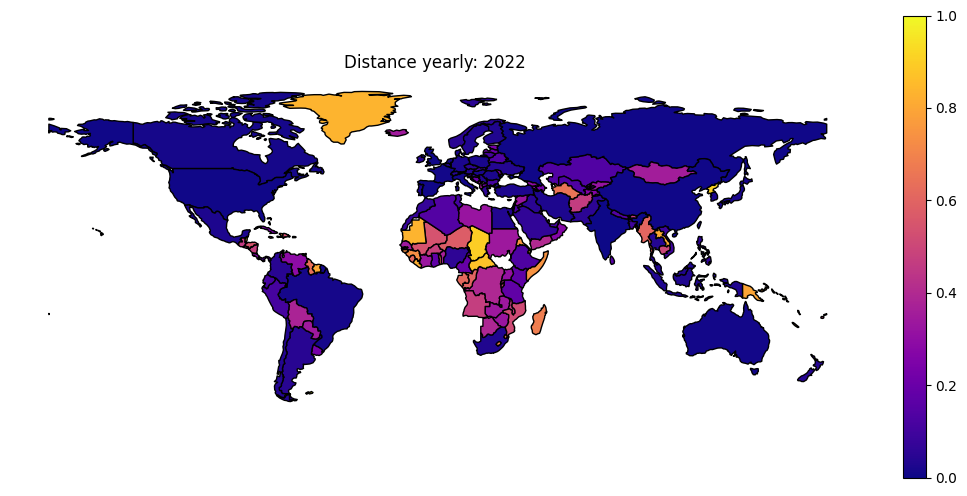

In [107]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"),
                       "dist_yearly", range=(0, 1), title=f"Distance yearly: {year}")


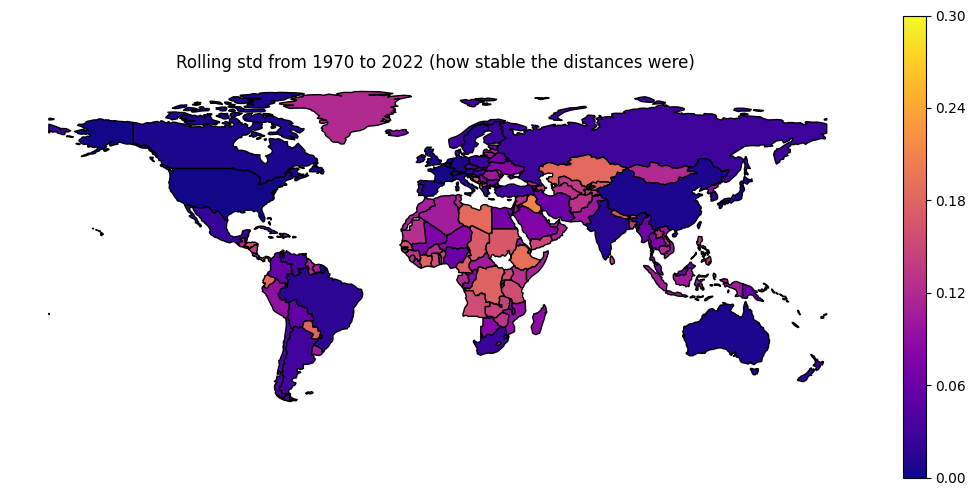

In [106]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"), "rolling_std", range=(0, 0.3),
                       title=f"Rolling std from {start_year} to {year} (how stable the distances were)")

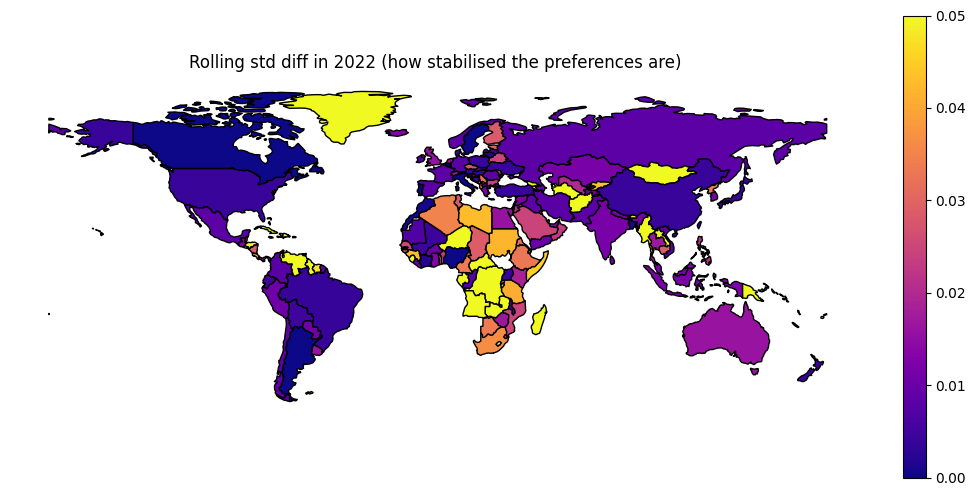

In [108]:
year = 2022
_, _, = uf.plot_map_continuous(df_dist_yearly.query("year==@year"), "rolling_std_diff", range=(0, 0.05),
                       title=f"Rolling std diff in {year} (how stabilised the preferences are)")

In [ ]:
uf.df_country

In [ ]:
uf.get_country_info("A")

In [104]:
country_list = ["US", "CN", "ID", "IN", "GB", "FR", "IT", "UA", "DZ", "CH", "BY", "KZ"]
px.line(
    (
        df_dist_yearly
        .query("country in @country_list")
    ),
    x="year",
    y="rolling_std",
    color="country",
    title=f"Rolling std from {start_year} to {year}",
)

In [110]:
country_list = ["US", "CN", "ID", "IN", "GB", "FR", "IT", "UA", "DZ", "CH", "BY", "KZ"]
px.line(
    (
        df_dist_yearly
        .query("country in @country_list")
    ),
    x="year",
    y="dist_yearly",
    color="country",
    title=f"Dist {start_year} to {year}",
)